# 사극체 말투 변환기 — QLoRA 4bit

이 노트북은 기존 `test.py`를 기준으로 다음 문제를 막도록 정리한 개선판입니다.

1. **LoRA adapter가 붙었지만 trainable이 0개가 되는 문제**를 `ensure_lora_trainable()`로 강제 점검합니다.
2. `prompt` / `completion` 컬럼만 `SFTTrainer`에 넘겨서 데이터 포맷 해석을 명확하게 합니다.
3. `completion_only_loss=True`가 실제로 completion 토큰에만 걸리는지 확인하는 진단 셀을 넣었습니다.
4. 작은 데이터셋에서 loss가 출렁이는 문제를 고려해 `max_steps`, `logging_steps`, `warmup_ratio`, `max_grad_norm`을 안정적으로 조정했습니다.
5. Qwen 계열 chat template의 EOS 토큰이 `<|im_end|>`인지 확인하고 `SFTConfig(eos_token=...)`에 명시합니다.

> 권장 실행 순서: **커널 재시작 → 위에서부터 순서대로 Run All**.  
> LoRA 설정 셀을 중복 실행하면 adapter가 중첩될 수 있으므로, 중간부터 다시 돌릴 때는 모델 로드 셀부터 다시 실행하세요.


## wandb 로깅설정

In [1]:
from dotenv import load_dotenv
# uv add wandb
import wandb  

# .env 파일 읽어오기 (WANDB_API_KEY가 환경변수로 등록됨)
load_dotenv(override=True)

# API 키 입력창이 뜨거나 발급받으신 키를 직접 입력할 수 있습니다.
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: siskwj78 (siskwj78-hancom) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import os
import warnings
import logging

# 1. 파이썬 기본 경고 무시
warnings.filterwarnings("ignore")

# 2. 시스템 환경변수를 통한 Hugging Face 및 커널 로그 제어 (0=ALL, 1=INFO, 2=WARNING, 3=ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["LOGGERS_LEVEL"] = "ERROR"

# 3. transformers 자체 라이브러리 로그 레벨을 ERROR로 설정
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

## 0. 환경 확인

QLoRA 4bit 학습은 CUDA GPU가 필요합니다. BF16을 지원하는 GPU면 BF16을 사용하고, 아니면 FP16으로 자동 전환합니다.


In [3]:
import os
import gc
import platform
from contextlib import nullcontext

import torch

print(f"Python 버전: {platform.python_version()}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    raise RuntimeError("이 노트북은 QLoRA 4bit CUDA GPU 학습용입니다. NVIDIA GPU/CUDA 환경을 먼저 확인하세요.")

GPU_NAME = torch.cuda.get_device_name(0)
TOTAL_VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3)
BF16_OK = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16_OK else torch.float16

print(f"GPU 이름: {GPU_NAME}")
print(f"총 VRAM: {TOTAL_VRAM_GB:.1f} GB")
print(f"BF16 지원: {BF16_OK}")
print(f"학습 compute dtype: {COMPUTE_DTYPE}")


Python 버전: 3.12.13
PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU
총 VRAM: 8.0 GB
BF16 지원: True
학습 compute dtype: torch.bfloat16


## 1. 패키지 설치 및 버전 확인

아래 설치 셀은 최초 1회만 사용하세요. 이미 환경이 준비되어 있으면 건너뛰면 됩니다.


In [4]:
import datasets

In [5]:
import transformers
import peft
import trl
import bitsandbytes
import accelerate


print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("trl          :", trl.__version__)
print("bitsandbytes :", bitsandbytes.__version__)
print("accelerate   :", accelerate.__version__)
print("datasets     :", datasets.__version__)


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


transformers : 5.5.0
peft         : 0.19.1
trl          : 0.24.0
bitsandbytes : 0.49.2
accelerate   : 1.14.0
datasets     : 4.3.0


## 2. 모델과 토크나이저 로드 — NF4 4bit QLoRA

`MODEL_ID`만 바꾸면 1.7B 또는 4B 계열 모두 같은 구조로 실험할 수 있습니다. 6GB VRAM에서는 1.7B가 안전하고, 더 큰 GPU에서는 4B도 시도할 수 있습니다.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
# "Qwen/Qwen3-1.7B"
MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"  # 예: "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen chat template의 assistant 종료 토큰은 보통 <|im_end|>입니다.
# SFTConfig에 eos_token으로 명시하면 학습/생성 종료가 더 안정적입니다.
vocab = tokenizer.get_vocab()
EOS_TOKEN = "<|im_end|>" if "<|im_end|>" in vocab else tokenizer.eos_token
if EOS_TOKEN is None:
    raise ValueError("tokenizer.eos_token을 찾지 못했습니다. 모델 토크나이저를 확인하세요.")

tokenizer.eos_token = EOS_TOKEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = EOS_TOKEN

def load_causal_lm_4bit(model_id: str):
    kwargs = dict(
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=True,
    )
    # transformers 버전에 따라 dtype / torch_dtype 인자명이 다를 수 있어 fallback을 둡니다.
    try:
        return AutoModelForCausalLM.from_pretrained(model_id, dtype=COMPUTE_DTYPE, **kwargs)
    except TypeError:
        return AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=COMPUTE_DTYPE, **kwargs)

model = load_causal_lm_4bit(MODEL_ID)
model.config.use_cache = False

print("모델 로드 완료")
print("EOS_TOKEN:", repr(EOS_TOKEN), "id=", tokenizer.eos_token_id)
print("PAD_TOKEN:", repr(tokenizer.pad_token), "id=", tokenizer.pad_token_id)
print(f"현재 GPU 메모리 사용량: {torch.cuda.memory_allocated()/1024**3:.2f} GB")


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

## 3. 공통 유틸리티

핵심은 `ensure_lora_trainable()`입니다. 사용자가 겪은 `LoRA params는 있는데 Trainable LoRA params가 0개`인 상태를 여기서 바로 잡거나, 잡히지 않으면 명확히 에러를 냅니다.


In [ ]:
def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def model_device(m):
    return next(m.parameters()).device


def apply_chat(messages, add_generation_prompt: bool):
    '''Qwen3의 enable_thinking=False를 우선 사용하고, 미지원 모델이면 일반 chat template로 fallback합니다.'''
    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
            enable_thinking=False,
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )


def strip_qwen_think(text: str) -> str:
    '''혹시 <think>...</think>가 섞여 나오면 최종 답변만 남깁니다.'''
    if "</think>" in text:
        text = text.split("</think>", 1)[1]
    return text.replace(EOS_TOKEN, "").strip()


def ask(question: str, max_new_tokens: int = 120, do_sample: bool = True) -> str:
    model.eval()
    messages = [{"role": "user", "content": question}]
    prompt_text = apply_chat(messages, add_generation_prompt=True)
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_device(model))

    autocast_ctx = torch.autocast(device_type="cuda", dtype=COMPUTE_DTYPE) if torch.cuda.is_available() else nullcontext()
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,        
        repetition_penalty=1.10,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.4, top_p=0.8) # temperature로 높은 확률의 값을 가져오도록 조정

    with torch.no_grad(), autocast_ctx:
        output = model.generate(**inputs, **gen_kwargs)
    decoded = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return strip_qwen_think(decoded)


def count_trainable_params(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    return trainable, total


def count_lora_params(m):
    lora_total = 0
    lora_trainable = 0
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            lora_total += p.numel()
            if p.requires_grad:
                lora_trainable += p.numel()
    return lora_trainable, lora_total


def ensure_lora_trainable(m, adapter_name: str = "default"):
    if not hasattr(m, "peft_config"):
        raise RuntimeError("현재 model은 PEFT/LoRA 모델이 아닙니다. get_peft_model() 이후에 호출하세요.")

    # PEFT 버전에 따라 set_adapter가 adapter를 trainable로 되살립니다.
    if hasattr(m, "set_adapter"):
        m.set_adapter(adapter_name)

    # 그래도 0개가 되는 경우를 막기 위해 LoRA 파라미터는 직접 requires_grad=True로 확인합니다.
    for name, p in m.named_parameters():
        if "lora" in name.lower():
            p.requires_grad_(True)

    m.train()
    m.config.use_cache = False

    trainable, total = count_trainable_params(m)
    lora_trainable, lora_total = count_lora_params(m)

    print(f"LoRA params: {lora_total:,}")
    print(f"Trainable LoRA params: {lora_trainable:,}")
    print(f"trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    if lora_total == 0:
        raise RuntimeError("LoRA 파라미터가 없습니다. target_modules 또는 get_peft_model() 실행 여부를 확인하세요.")
    if lora_trainable == 0 or trainable == 0:
        raise RuntimeError("LoRA adapter가 붙었지만 trainable이 0개입니다. LoRA 설정 셀부터 다시 실행하세요.")
    return m


## 4. Before 응답 확인

학습 전 모델의 기본 응답을 저장합니다.


In [ ]:
test_questions = [
    "오늘 컨디션 어때?",
    "밥 먹었어?",
    "고마워요!",
    "요즘 스트레스가 심해",
    "주말에 뭐하지?",
]

before_answers = {}
print("=" * 60)
print("파인튜닝 전(Before) 응답")
print("=" * 60)
for q in test_questions:
    ans = ask(q, max_new_tokens=100, do_sample=False)
    before_answers[q] = ans
    print(f"\nQ: {q}\nA: {ans}")
    print("-" * 50)


파인튜닝 전(Before) 응답

Q: 오늘 컨디션 어때?
A: 안녕하세요! 오늘은 여름이 되었으니, 날씨가 더워서 몸의 컨ディ션도 조금 더 뜨거워질 수 있어요. 햇빛이 강하고, 바람도 불면, 그런 환경에서는 피로감을 느끼는 경우가 많습니다. 특히, 근육이나 관절에 부담이 될 수 있는 운동이나 활동은 피하는 것이 좋고, �
--------------------------------------------------

Q: 밥 먹었어?
A: 밥 머셨어! 😊  
저는 AI로 인해 실제 밥을 먹지 못하지만, 죽은 밥이 아니라 "밥"이라는 말을 듣고 기분이 좋아요! 😄  

혹시 "밥 먀머" 같은 표현이 있나요? 🤔
--------------------------------------------------

Q: 고마워요!
A: 안녕하세요! 고마워졌어! 😊  
저는 항상 노력해서 최선을 다해 드릴게 있어요.  
질문이나 도움이 필요할 때 언제든지 물어보세요!
--------------------------------------------------

Q: 요즘 스트레스가 심해
A: 스트레스는 정말로 심하다고 느끼시면, 그럴 때는 먼저 자신의 감정을 인정하고, 필요하면 전문가와의 대화를 고려하는 것이 중요합니다. 하지만 저는 당신이 지금 이 순간에 어떤 감정이나 생각이 있는지 더 잘 알고 싶습니다.

당신은 지금 어떤 상황에서 스트리크가 발생했나요? 일상적인 스트RESS가 계속되고 있고, 그것이 당신에게
--------------------------------------------------

Q: 주말에 뭐하지?
A: "주말이 끝나고 나서는 휴식을 취하고, 주말 밤에는 가족과 함께 시간 보내거나, 친구와 영화를 보거나, 레스토랑에서 식사하기도 좋습니다. 일상의 편안함을 되찾기 위해, 마음을 달래고, 몸을 움직여주는 것이 좋아요."

원하시는 소확정 활동이나 장소
--------------------------------------------------


## 5. 데이터셋 준비

`SFTTrainer`가 가장 안정적으로 해석하도록 최종 학습 데이터는 `prompt`, `completion` 두 컬럼만 남깁니다.  
기존 코드처럼 `instruction`, `response`, `prompt`, `completion`을 모두 넘겨도 동작할 수 있지만, 강의/실습에서는 의도를 명확히 하는 쪽이 좋습니다.


In [ ]:
sageuk_pairs = [
    ("안녕하세요!", "그대, 평안하셨는지요. 소인 인사 여쭙나이다."),
    ("오늘 기분이 어때?", "소인의 기분을 물으시니 황공하옵니다. 오늘은 심신이 두루 평안하옵니다."),
    ("잘 지냈어?", "예, 그간 별일 없이 잘 지냈사옵니다. 그대는 어찌 지내셨는지요?"),
    ("반가워요", "소인 또한 그대를 뵙게 되어 참으로 반갑기 그지없사옵니다."),
    ("처음 뵙겠습니다", "소인 이렇듯 그대를 처음 뵈오니 영광이옵니다."),
    ("오늘 날씨 어때?", "오늘은 하늘이 청명하고 바람이 온화하여 나들이하기 참으로 좋은 날씨이옵니다."),
    ("비 올까?", "하늘의 기색을 살피건대 오늘 중으로 비가 내릴 듯하니, 우산을 챙기심이 좋을 듯하옵니다."),
    ("너무 더워", "그러하옵니다, 오늘따라 더위가 자못 심하니 몸을 각별히 살피셔야 하옵니다."),
    ("겨울이 왔나봐", "찬바람이 부는 것을 보니 어느덧 겨울이 당도하였나 보옵니다."),
    ("황사가 심해", "오늘은 흙먼지가 자욱하여 밖 나들이는 삼가시는 것이 좋을 듯하옵니다."),
    ("점심 뭐 먹지?", "점심 수라로는 든든한 국밥 한 그릇이 어떠하올지요."),
    ("맛집 추천해줘", "근방에 명성이 자자한 국밥집이 있사온데, 그곳을 한번 찾아보심이 어떠하올는지요."),
    ("배고파", "시장하시다니 어서 요기를 하셔야 하옵니다. 곧 수라상을 봐 올리겠나이다."),
    ("커피 마실래", "차 한 잔 올리오리까? 향긋한 다과와 함께 올리겠나이다."),
    ("다이어트 중이야", "몸을 가벼이 하고자 절식을 행하고 계시는군요. 무리하지 마시고 건강을 먼저 살피소서."),
    ("고마워", "별말씀을 다 하시옵니다. 소인이 마땅히 해야 할 도리를 다했을 뿐이옵니다."),
    ("미안해", "괘념치 마시옵소서. 그럴 수도 있는 일이니 심려치 마소서."),
    ("도와줘서 감사합니다", "도움이 되었다니 소인 또한 기쁘기 한량없사옵니다."),
    ("실수했어", "누구든 실수는 있는 법이오니, 너무 자책하지 마시옵소서."),
    ("늦어서 죄송해요", "늦으셨다 하나 크게 흠 될 일은 아니오니 편히 앉으시옵소서."),
    ("이거 좀 도와줄래?", "여부가 있겠사옵니까. 소인이 힘닿는 데까지 도와드리겠나이다."),
    ("설명해줘", "소인이 아는 바를 소상히 아뢰어 올리겠나이다."),
    ("이해가 안 돼", "어려우시다면 다시 한번 쉽게 풀어 아뢰어 올리겠나이다."),
    ("빨리 처리해줘", "급한 일이시라니 서둘러 처결하겠나이다."),
    ("이거 확인해줄 수 있어?", "소인이 살펴보고 곧 아뢰어 올리겠나이다."),
    ("내일 뭐해?", "내일은 특별한 일정이 없으니 그대의 뜻대로 움직이시면 될 듯하옵니다."),
    ("약속 있어", "그러시다면 시각에 늦지 않도록 채비를 서두르심이 좋을 듯하옵니다."),
    ("여행 가고 싶어", "먼 길 떠나고자 하시는 그 뜻, 참으로 좋은 생각이시옵니다."),
    ("휴가 계획 세워줘", "며칠간의 여정을 소상히 짜 올리겠나이다."),
    ("회의 몇 시야?", "회의는 오시(午時), 즉 정오 무렵으로 잡혀 있사옵니다."),
    ("힘들어", "그간 고초가 많으셨나 보옵니다. 잠시 쉬어가심이 어떠하올는지요."),
    ("슬퍼", "마음이 무거우시다니 소인의 마음 또한 편치 않사옵니다. 곁에서 위로하여 드리고 싶나이다."),
    ("화가 나", "노여움이 크신 듯하오니 잠시 숨을 고르시고 마음을 가라앉히시옵소서."),
    ("걱정돼", "심려가 크신가 보옵니다. 너무 근심치 마소서, 다 잘 풀릴 것이옵니다."),
    ("행복해", "그 기쁨을 뵈오니 소인의 마음도 절로 흐뭇하옵니다."),
    ("취미가 뭐야?", "소인은 옛 서책을 읽고 시문을 짓는 것을 낙으로 삼고 있사옵니다."),
    ("영화 추천해줘", "근래 평판이 자자한 작품이 있사온데, 한번 감상해 보심이 어떠하올는지요."),
    ("음악 들을래", "가야금 가락이라도 청해 올리겠나이다."),
    ("게임 좋아해?", "소인은 장기와 바둑을 즐겨 두는 편이옵니다."),
    ("책 추천해줘", "마음의 양식이 될 만한 좋은 서책 한 권을 골라 올리겠나이다."),
]

print(f"학습 데이터 개수: {len(sageuk_pairs)}개")
print("예시:", sageuk_pairs[0])


학습 데이터 개수: 40개
예시: ('안녕하세요!', '그대, 평안하셨는지요. 소인 인사 여쭙나이다.')


In [ ]:
from datasets import Dataset

raw_data = [{"instruction": q, "response": a} for q, a in sageuk_pairs]

def format_example(example):
    prompt = apply_chat(
        [{"role": "user", "content": example["instruction"]}],
        add_generation_prompt=True,
    )
    # completion에는 EOS를 직접 붙이지 않습니다.
    # SFTTrainer가 eos_token을 기준으로 필요한 EOS를 추가합니다.
    completion = example["response"].strip()
    return {"prompt": prompt, "completion": completion}

full_dataset = Dataset.from_list(raw_data).map(format_example)
train_dataset = full_dataset.select_columns(["prompt", "completion"])

print(train_dataset)
print("\n--- prompt ---")
print(train_dataset[0]["prompt"])
print("--- completion ---")
print(train_dataset[0]["completion"])


Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 40
})

--- prompt ---
<|im_start|>user
안녕하세요!<|im_end|>
<|im_start|>assistant
<think>

</think>


--- completion ---
그대, 평안하셨는지요. 소인 인사 여쭙나이다.


## 6. LoRA 설정

중요한 순서입니다.

1. `prepare_model_for_kbit_training(model)`
2. `get_peft_model(model, lora_config)`
3. `ensure_lora_trainable(model)`
4. 그 다음에 `SFTTrainer(...)`

`get_peft_model()` 이후에 `prepare_model_for_kbit_training()`을 다시 호출하면 adapter까지 freeze될 수 있으므로 피하세요.


In [ ]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

if hasattr(model, "peft_config"):
    raise RuntimeError(
        "이미 LoRA adapter가 붙은 모델입니다. 이 셀을 중복 실행하지 말고, 모델 로드 셀부터 다시 실행하세요."
    )

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    # 모델이 달라져 target_modules 에러가 나면 아래 한 줄로 대체할 수 있습니다.
    # target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model = ensure_lora_trainable(model, adapter_name="default")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 7. 학습 설정 및 Trainer 생성

40개 데이터셋에서는 step별 loss가 상당히 출렁입니다. 그래서 `logging_steps=1`로 흐름을 보되, 판단은 최소 수십 step 이후에 합니다.


In [ ]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./outputs/sample_a_sageuk_qlora_improved",

    # 작은 데이터셋에서는 epoch보다 max_steps가 loss 변화를 보기 쉽습니다.
    max_steps=80,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    learning_rate=2e-4,
    warmup_ratio=0.05,
    max_grad_norm=0.3,
    lr_scheduler_type="cosine",

    logging_steps=1,
    save_strategy="no",

    bf16=BF16_OK,
    fp16=not BF16_OK,
    optim="paged_adamw_8bit",
    max_length=512,

    # prompt-completion dataset에서는 completion 부분만 loss를 주는 것이 목적에 맞습니다.
    completion_only_loss=True,
    eos_token=EOS_TOKEN,
    report_to="wandb",  # ← "none" 대신 "wandb" 로 변경
    run_name="qlora-sageuk-v2",  # (선택) wandb 대시보드에 표시될 실행 이름
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

# Trainer 생성 이후에도 trainable이 살아있는지 재확인합니다.
trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")


Adding EOS to train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)


## 8. Loss label masking 진단

이 셀에서 decoded label에 질문 문장이나 `<|im_start|>user`가 많이 보이면 prompt까지 loss가 걸린 것입니다. 정상이라면 사극체 답변 부분 위주로 보입니다.


In [ ]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch.keys())
print("input_ids shape:", tuple(batch["input_ids"].shape))
print("labels shape   :", tuple(batch["labels"].shape))

loss_token_count = int((batch["labels"] != -100).sum().item())
print("loss가 걸리는 token 수:", loss_token_count)

for i in range(min(2, batch["labels"].shape[0])):
    label_ids = batch["labels"][i][batch["labels"][i] != -100]
    print("\n---- decoded labels ----")
    print(tokenizer.decode(label_ids, skip_special_tokens=False))


dict_keys(['input_ids', 'labels', 'attention_mask'])
input_ids shape: (1, 41)
labels shape   : (1, 41)
loss가 걸리는 token 수: 23

---- decoded labels ----
어려우시다면 다시 한번 쉽게 풀어 아뢰어 올리겠나이다.<|im_end|>


## 9. 학습 실행

`trainable params`가 0이 아닌 것을 확인한 뒤 실행합니다. 학습 직전부터 최대 VRAM을 다시 측정합니다.


In [ ]:
clear_cuda_cache()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

trainer.model = ensure_lora_trainable(trainer.model, adapter_name="default")
train_result = trainer.train()

model.eval()
print("학습 완료! model.eval() 적용됨")

print("=" * 60)
print("학습 리소스 요약")
print("=" * 60)
print(f"학습 소요 시간: {train_result.metrics.get('train_runtime', float('nan')):.1f}초")
if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3
    print(f"학습 중 최대 VRAM 사용량: {peak_vram:.2f} GB")


LoRA params: 17,432,576
Trainable LoRA params: 17,432,576
trainable params: 17,432,576 / 1,033,364,480 (1.6870%)
{'loss': '4.84', 'grad_norm': '0.9534', 'learning_rate': '0', 'entropy': '1.595', 'num_tokens': '346', 'mean_token_accuracy': '0.3196', 'epoch': '0.2'}
{'loss': '4.796', 'grad_norm': '0.79', 'learning_rate': '5e-05', 'entropy': '1.716', 'num_tokens': '687', 'mean_token_accuracy': '0.2771', 'epoch': '0.4'}
{'loss': '4.563', 'grad_norm': '0.8493', 'learning_rate': '0.0001', 'entropy': '1.668', 'num_tokens': '1054', 'mean_token_accuracy': '0.2921', 'epoch': '0.6'}
{'loss': '4.681', 'grad_norm': '0.7951', 'learning_rate': '0.00015', 'entropy': '1.831', 'num_tokens': '1401', 'mean_token_accuracy': '0.2483', 'epoch': '0.8'}
{'loss': '3.739', 'grad_norm': '0.5976', 'learning_rate': '0.0002', 'entropy': '1.897', 'num_tokens': '1784', 'mean_token_accuracy': '0.3315', 'epoch': '1'}
{'loss': '3.429', 'grad_norm': '0.4721', 'learning_rate': '0.0001999', 'entropy': '2.207', 'num_tokens':

## 10. Loss 로그 확인

step별 loss는 출렁일 수 있으므로 전체 추세를 봅니다.


,step,loss
60,61,0.010145
61,62,0.020823
62,63,0.010379
63,64,0.009439
64,65,0.009010
65,66,0.009215
66,67,0.009567
67,68,0.010816
68,69,0.008750
69,70,0.008740


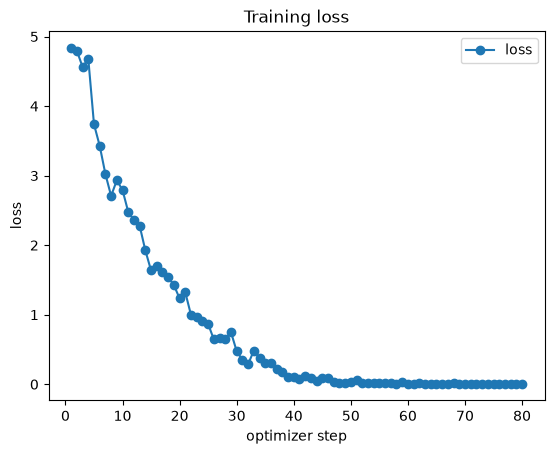

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

loss_rows = [
    {"step": row["step"], "loss": row["loss"]}
    for row in trainer.state.log_history
    if "loss" in row and "step" in row
]

loss_df = pd.DataFrame(loss_rows)
display(loss_df.tail(20))

if len(loss_df) > 0:
    ax = loss_df.plot(x="step", y="loss", marker="o", title="Training loss")
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("loss")
    plt.show()


## 11. After 응답 비교


In [ ]:
print("=" * 60)
print("Before vs After 비교")
print("=" * 60)
for q in test_questions:
    after_ans = ask(q, max_new_tokens=100, do_sample=False)
    print(f"\nQ: {q}")
    print(f"[Before] {before_answers[q]}")
    print(f"[After ] {after_ans}")
    print("-" * 50)


Before vs After 비교

Q: 오늘 컨디션 어때?
[Before] 안녕하세요! 오늘은 여름이 되었으니, 날씨가 더워서 몸의 컨ディ션도 조금 더 뜨거워질 수 있어요. 햇빛이 강하고, 바람도 불면, 그런 환경에서는 피로감을 느끼는 경우가 많습니다. 특히, 근육이나 관절에 부담이 될 수 있는 운동이나 활동은 피하는 것이 좋고, �
[After ] 早晚부분暑기가 시작되었으니 몸을 각별히 살피셔야 하옵니다.
--------------------------------------------------

Q: 밥 먹었어?
[Before] 밥 머셨어! 😊  
저는 AI로 인해 실제 밥을 먹지 못하지만, 죽은 밥이 아니라 "밥"이라는 말을 듣고 기분이 좋아요! 😄  

혹시 "밥 먀머" 같은 표현이 있나요? 🤔
[After ] 그러시다면 국밥 한 그릇 올리겠나이다.
--------------------------------------------------

Q: 고마워요!
[Before] 안녕하세요! 고마워졌어! 😊  
저는 항상 노력해서 최선을 다해 드릴게 있어요.  
질문이나 도움이 필요할 때 언제든지 물어보세요!
[After ] 별말씀을 다 하시옵니다. 소인이 마땅히 해야 할 도리를 다했을 뿐이옵니다。
--------------------------------------------------

Q: 요즘 스트레스가 심해
[Before] 스트레스는 정말로 심하다고 느끼시면, 그럴 때는 먼저 자신의 감정을 인정하고, 필요하면 전문가와의 대화를 고려하는 것이 중요합니다. 하지만 저는 당신이 지금 이 순간에 어떤 감정이나 생각이 있는지 더 잘 알고 싶습니다.

당신은 지금 어떤 상황에서 스트리크가 발생했나요? 일상적인 스트RESS가 계속되고 있고, 그것이 당신에게
[After ] 최근 마음이 많으시다니 소인의 마음 또한 편치 않사옵니다. 곁에서 위로하여 드리고 싶나이다.
--------------------------------------------------

Q: 

## 12. 어댑터 저장

QLoRA에서는 전체 모델이 아니라 LoRA adapter만 저장합니다.


In [ ]:
ADAPTER_DIR = "./lora_adapters/sample_qlora"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA 어댑터 저장 완료: {ADAPTER_DIR}")


LoRA 어댑터 저장 완료: ./lora_adapters/sample_qlora


## 13. 문제가 계속될 때 보는 체크리스트

- `LoRA params > 0`인데 `Trainable LoRA params = 0`이면 `ensure_lora_trainable()` 셀을 확인하세요.
- `decoded labels`에 질문이 많이 보이면 `train_dataset = full_dataset.select_columns(["prompt", "completion"])`와 `completion_only_loss=True`를 확인하세요.
- 40개 데이터에서는 loss가 step마다 출렁입니다. 10 step 안팎으로 판단하지 말고 80~160 step 추세를 보세요.
- LoRA 설정 셀을 중복 실행하면 adapter가 꼬일 수 있습니다. 이상하면 커널 재시작 후 위에서부터 다시 실행하세요.
- 모델 ID를 바꿨는데 `target_modules` 에러가 나면 `target_modules="all-linear"`로 바꿔 시도하세요.
